# Analysis of First Student Assistant Pilot

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import ast


In [7]:
data = pd.read_csv('/Users/nicolasroever/Documents/Promotion/Bargaining/bargaining_experiment_analysis/src/template_project/data/Data_Pilot_1_Student_Assistants/Results_Pilot_Student_Assistants.csv')

## Costs in the Treatment

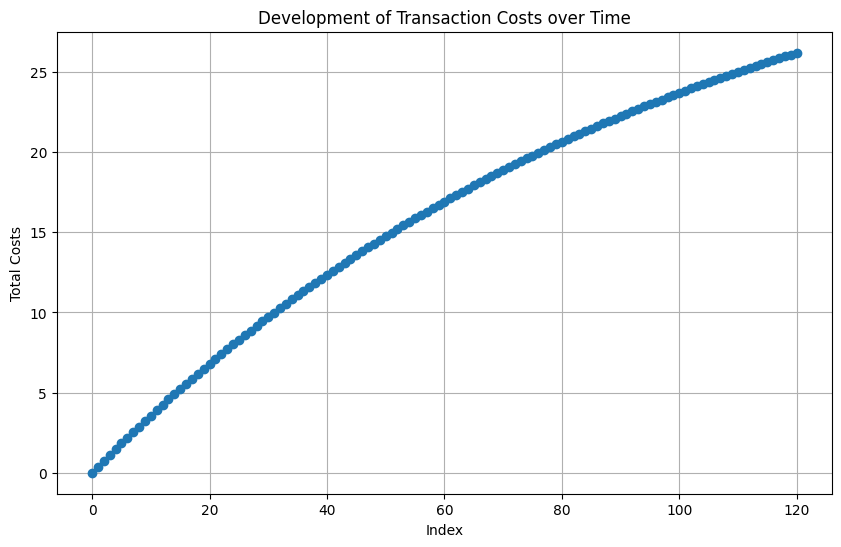

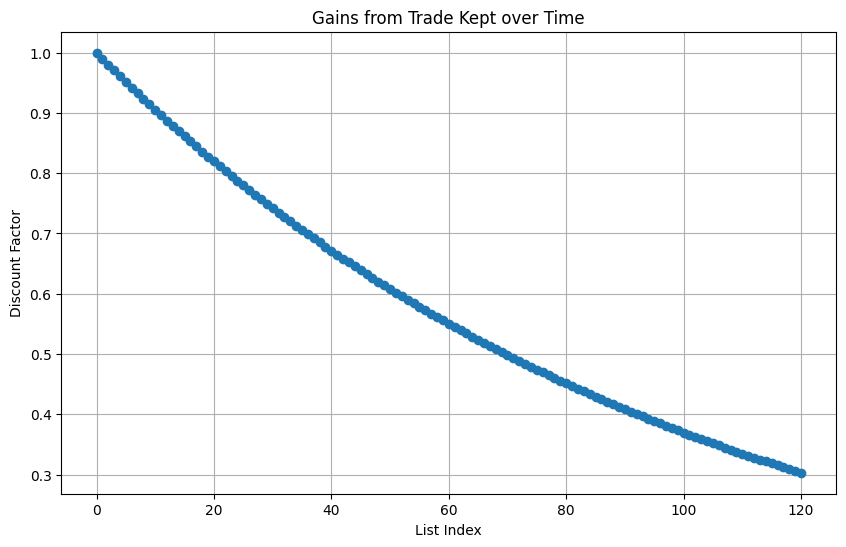

In [14]:

# Extract the total_costs_list and discount_factors_list for player 1 in round 1
player_1_costs = data.loc[0, 'bargain_live.1.player.total_costs_list']
player_1_discount_factors = data.loc[0, 'bargain_live.1.player.discount_factors_list']

# Convert the string representations of the lists to actual lists
player_1_costs_list = ast.literal_eval(player_1_costs)
player_1_discount_factors_list = ast.literal_eval(player_1_discount_factors)

# Plot 1: Total costs with the index on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(range(len(player_1_costs_list)), player_1_costs_list, marker='o')
plt.xlabel('Index')
plt.ylabel('Total Costs')
plt.title('Development of Transaction Costs over Time')
plt.grid(True)
plt.show()

# Plot 2: Discount factors with the list index on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(player_1_discount_factors_list, marker='o')
plt.xlabel('List Index')
plt.ylabel('Discount Factor')
plt.title('Gains from Trade Kept over Time')
plt.grid(True)
plt.show()

## Realized Gains from Trade

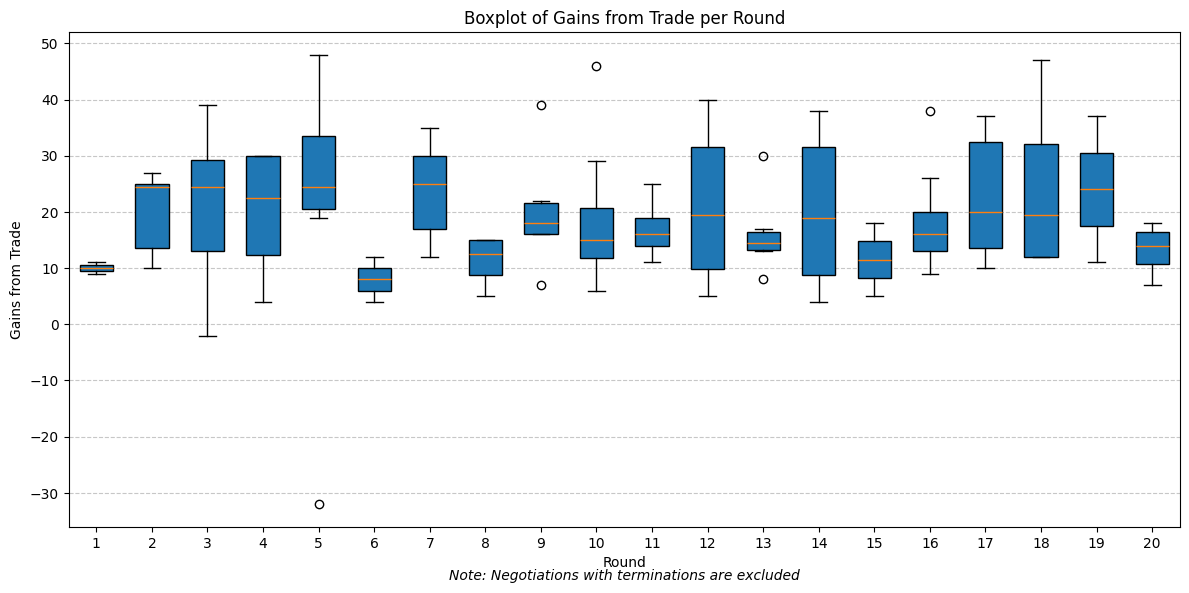

In [9]:
# Initialize a list to store gains from trade for each round
gains_from_trade = []

for i in range(1, 21):
    # Calculate gains for buyers
    buyer_gains = data[f'bargain_live.{i}.player.valuation'] - data[f'bargain_live.{i}.group.deal_price']
    buyer_gains[data[f'bargain_live.{i}.player.role'] != 'Buyer'] = pd.NA
    
    # Calculate gains for sellers
    seller_gains = data[f'bargain_live.{i}.group.deal_price'] - data[f'bargain_live.{i}.player.valuation']
    seller_gains[data[f'bargain_live.{i}.player.role'] != 'Seller'] = pd.NA
    
    # Combine gains for both buyers and sellers
    gains = pd.concat([buyer_gains, seller_gains], axis=0).dropna()
    gains_from_trade.append(gains)

# Create a boxplot of gains from trade for each round
plt.figure(figsize=(12, 6))
plt.boxplot(gains_from_trade, positions=range(1, 21), widths=0.6, patch_artist=True)

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Gains from Trade')
plt.title('Boxplot of Gains from Trade per Round')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 21))

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add note about excluded negotiations
plt.text(0.5, -0.1, 'Note: Negotiations with terminations are excluded', 
         ha='center', va='center', transform=plt.gca().transAxes, fontsize=10, style='italic')

# Show the plot
plt.tight_layout()
plt.show()

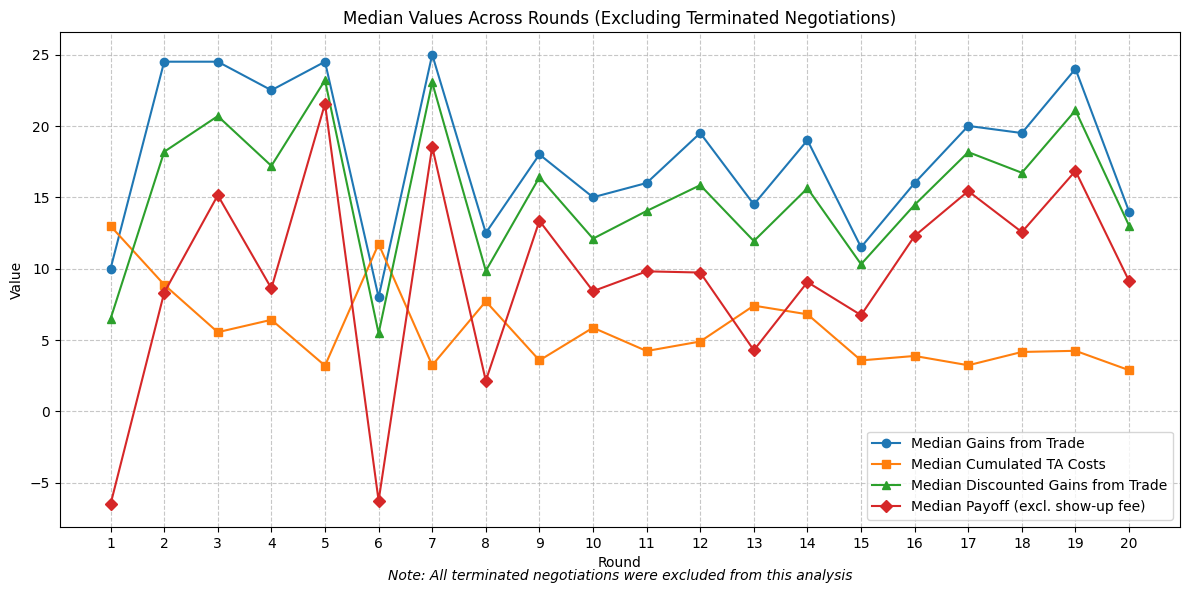

In [18]:
# Calculate gains from trade for each round
gains_from_trade = []
cumulated_TA_costs = []
discounted_gains_from_trade = []
payoffs_excluding_fee = []
payoffs_including_fee = []

for i in range(1, 21):
    # Filter out terminated negotiations
    round_data = data[data[f'bargain_live.{i}.group.terminated'] != 1]
    
    # Calculate gains for buyers and sellers
    buyer_gains = round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price']
    seller_gains = round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    gains = pd.concat([buyer_gains, seller_gains])
    gains_from_trade.append(gains.median())
    
    # Calculate cumulated TA costs
    cumulated_TA_costs.append(round_data[f'bargain_live.{i}.player.cumulated_TA_costs'].median())
    
    # Calculate discounted gains from trade
    discount_factor = round_data[f'bargain_live.{i}.player.current_discount_factor']
    discounted_gains = gains * discount_factor
    discounted_gains_from_trade.append(discounted_gains.median())
    
    # Calculate median payoff (excluding show-up fee)
    payoffs_excluding_fee.append(round_data[f'bargain_live.{i}.player.payoff'].median())
    
    # Calculate median payoff (including show-up fee)
    payoffs_including_fee.append((round_data[f'bargain_live.{i}.player.payoff'] + 20).median())

# Create the plot
plt.figure(figsize=(12, 6))

# Plot median gains from trade
plt.plot(range(1, 21), gains_from_trade, marker='o', label='Median Gains from Trade')

# Plot median cumulated TA costs
plt.plot(range(1, 21), cumulated_TA_costs, marker='s', label='Median Cumulated TA Costs')

# Plot median discounted gains from trade
plt.plot(range(1, 21), discounted_gains_from_trade, marker='^', label='Median Discounted Gains from Trade')

# Plot median payoff (excluding show-up fee)
plt.plot(range(1, 21), payoffs_excluding_fee, marker='D', label='Median Payoff (excl. show-up fee)')

# Plot median payoff (including show-up fee)
#plt.plot(range(1, 21), payoffs_including_fee, marker='*', label='Median Payoff (incl. show-up fee)')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Value')
plt.title('Median Values Across Rounds (Excluding Terminated Negotiations)')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 21))

# Add a grid for easier reading
plt.grid(axis='both', linestyle='--', alpha=0.7)

# Add legend
plt.legend()

# Add note about excluded negotiations
plt.text(0.5, -0.1, 'Note: All terminated negotiations were excluded from this analysis', 
         ha='center', va='center', transform=plt.gca().transAxes, fontsize=10, style='italic')

# Show the plot
plt.tight_layout()
plt.show()

## Deal Prices

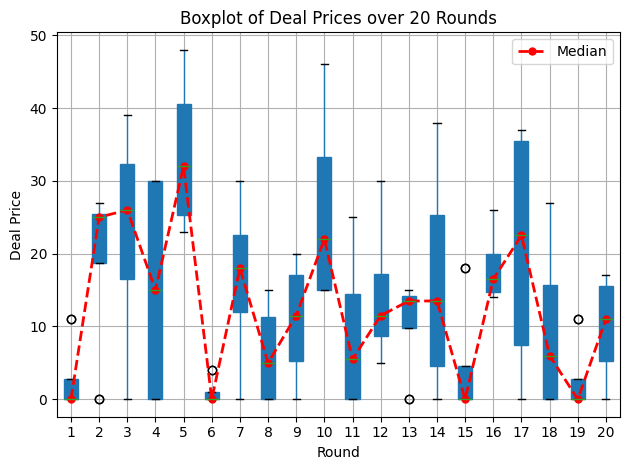

In [3]:
# Extract all deal_price columns for the 20 rounds
deal_price_columns = [f'bargain_live.{i}.group.deal_price' for i in range(1, 21)]

# Filter the relevant data (deal prices for 20 rounds)
deal_prices = data[deal_price_columns]

# Replace NaN values with 0
deal_prices = deal_prices.fillna(0)

# Create a boxplot for each round and fill the boxes
boxplot = deal_prices.boxplot(column=deal_price_columns, grid=True, patch_artist=True)

# Fill the boxes with color
for box in boxplot.artists:
    box.set_facecolor('lightblue')

# Draw a line through the medians
medians = deal_prices.median()
plt.plot(range(1, 21), medians, color='red', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Deal Price')
plt.title('Boxplot of Deal Prices over 20 Rounds')

# Set x-axis labels to number from 1 to 20
boxplot.set_xticklabels(range(1, 21))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


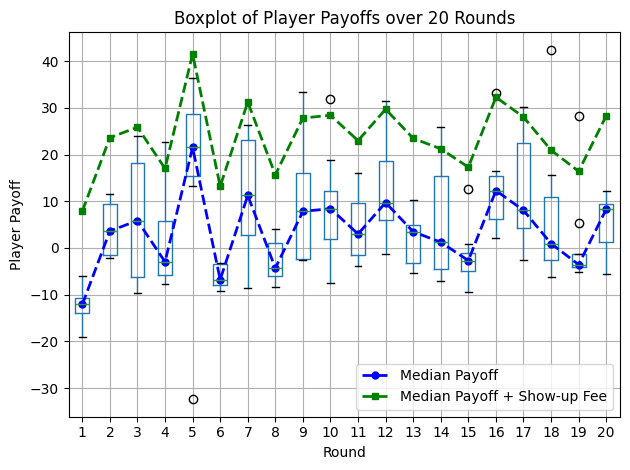

In [19]:
# Extract all player_payoff columns for the 20 rounds
player_payoff_columns = [f'bargain_live.{i}.player.payoff' for i in range(1, 21)]

# Filter the relevant data (player payoffs for 20 rounds)
player_payoffs = data[player_payoff_columns]

# Replace NaN values with 0
player_payoffs = player_payoffs.fillna(0)

# Create a boxplot for each round
boxplot_payoff = player_payoffs.boxplot(column=player_payoff_columns, grid=True)

# Draw a line through the medians
medians_payoff = player_payoffs.median()
plt.plot(range(1, 21), medians_payoff, color='blue', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Payoff')

# Draw a line for median payoff plus show-up fee
medians_payoff_with_fee = medians_payoff + 20
plt.plot(range(1, 21), medians_payoff_with_fee, color='green', marker='s', linestyle='dashed', linewidth=2, markersize=5, label='Median Payoff + Show-up Fee')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Player Payoff')
plt.title('Boxplot of Player Payoffs over 20 Rounds')

# Set x-axis labels to number from 1 to 20
boxplot_payoff.set_xticklabels(range(1, 21))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

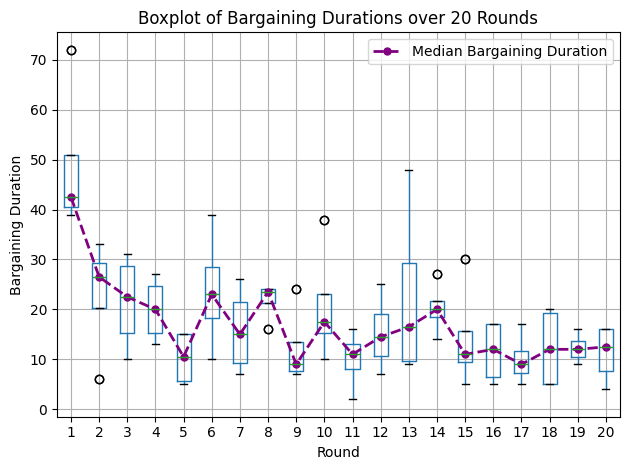

In [5]:
# Extract all bargaining_duration columns for the 20 rounds
bargaining_duration_columns = [f'bargain_live.{i}.group.bargaining_duration' for i in range(1, 21)]

# Filter the relevant data (bargaining durations for 20 rounds)
bargaining_durations = data[bargaining_duration_columns]

# Replace NaN values with 0 (if necessary)
bargaining_durations = bargaining_durations.fillna(0)

# Create a boxplot for each round
boxplot_bargaining_duration = bargaining_durations.boxplot(column=bargaining_duration_columns, grid=True)

# Draw a line through the medians
medians_bargaining_duration = bargaining_durations.median()
plt.plot(range(1, 21), medians_bargaining_duration, color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Bargaining Duration')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Bargaining Duration')
plt.title('Boxplot of Bargaining Durations over 20 Rounds')

# Set x-axis labels to number from 1 to 20
boxplot_bargaining_duration.set_xticklabels(range(1, 21))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

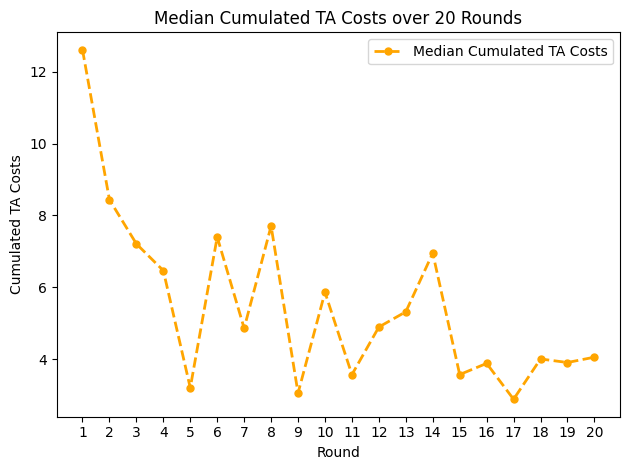

In [6]:
# Extract all cumulated_TA_costs columns for the 20 rounds
cumulated_TA_costs_columns = [f'bargain_live.{i}.player.cumulated_TA_costs' for i in range(1, 21)]

# Filter the relevant data (cumulated TA costs for 20 rounds)
cumulated_TA_costs = data[cumulated_TA_costs_columns]

# Replace NaN values with 0
cumulated_TA_costs = cumulated_TA_costs.fillna(0)

# Calculate the median cumulated TA costs
medians_cumulated_TA_costs = cumulated_TA_costs.median()

# Plot the median cumulated TA costs
plt.plot(range(1, 21), medians_cumulated_TA_costs, color='orange', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Cumulated TA Costs')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Cumulated TA Costs')
plt.title('Median Cumulated TA Costs over 20 Rounds')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 21))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

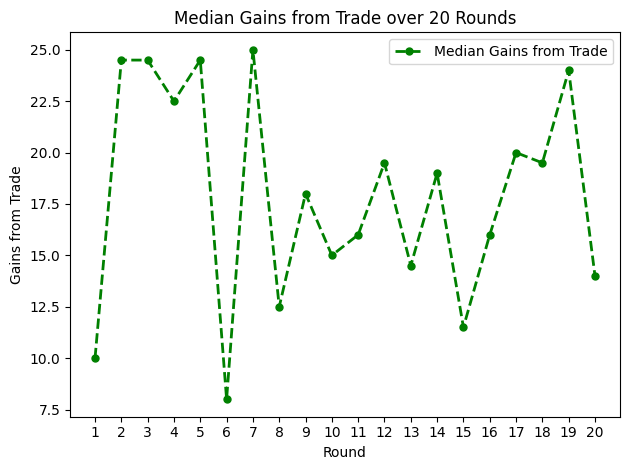

In [7]:
# Calculate gains from trade for each round
gains_from_trade = []
for i in range(1, 21):
    buyer_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price']
    seller_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    gains_from_trade.append(pd.concat([buyer_gains, seller_gains]))

# Concatenate all rounds and calculate median gains from trade
gains_from_trade_df = pd.concat(gains_from_trade, axis=1)
medians_gains_from_trade = gains_from_trade_df.median(axis=0)

# Plot the median gains from trade
plt.plot(range(1, 21), medians_gains_from_trade, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Gains from Trade')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Gains from Trade')
plt.title('Median Gains from Trade over 20 Rounds')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 21))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

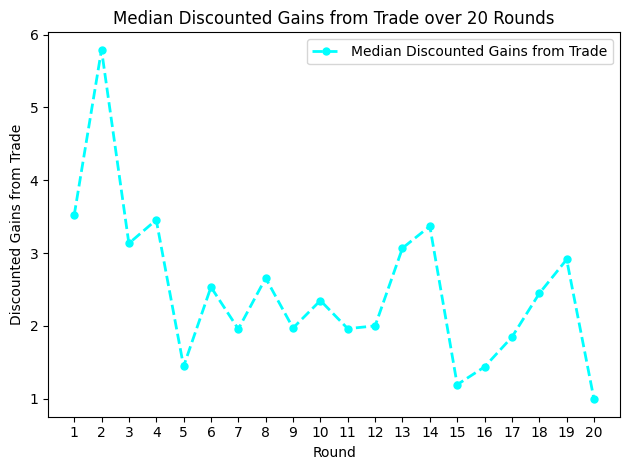

In [8]:
# Calculate discounted gains from trade for each round
discounted_gains_from_trade = []
for i in range(1, 21):
    # Calculate gains for buyers and sellers
    buyer_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price']
    seller_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    
    # Combine gains
    gains = pd.concat([buyer_gains, seller_gains])
    
    # Get the discount factor
    discount_factor = data[f'bargain_live.{i}.player.current_discount_factor']
    
    # Calculate discounted gains
    discounted_gains = gains * (1 - discount_factor)
    discounted_gains_from_trade.append(discounted_gains)

# Concatenate all rounds and calculate median discounted gains from trade
discounted_gains_from_trade_df = pd.concat(discounted_gains_from_trade, axis=1)
medians_discounted_gains_from_trade = discounted_gains_from_trade_df.median(axis=0)

# Plot the median discounted gains from trade
plt.plot(range(1, 21), medians_discounted_gains_from_trade, color='cyan', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Discounted Gains from Trade')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Discounted Gains from Trade')
plt.title('Median Discounted Gains from Trade over 20 Rounds')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 21))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

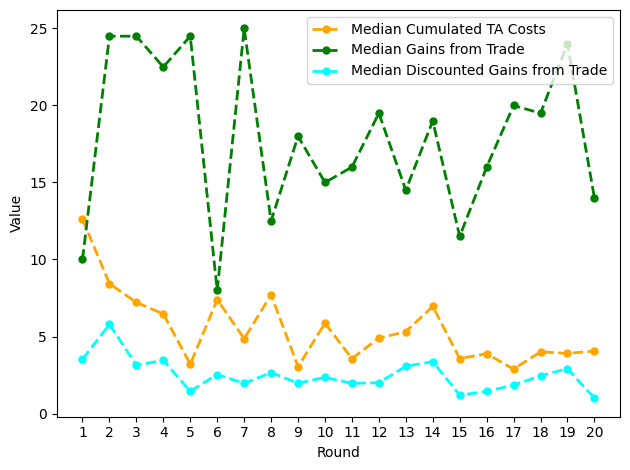

In [9]:
# Extract and calculate median cumulated TA costs
cumulated_TA_costs_columns = [f'bargain_live.{i}.player.cumulated_TA_costs' for i in range(1, 21)]
cumulated_TA_costs = data[cumulated_TA_costs_columns].fillna(0)
medians_cumulated_TA_costs = cumulated_TA_costs.median()

# Calculate median gains from trade
gains_from_trade = []
for i in range(1, 21):
    buyer_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price']
    seller_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    gains_from_trade.append(pd.concat([buyer_gains, seller_gains]))
gains_from_trade_df = pd.concat(gains_from_trade, axis=1)
medians_gains_from_trade = gains_from_trade_df.median(axis=0)

# Calculate median discounted gains from trade
discounted_gains_from_trade = []
for i in range(1, 21):
    gains = pd.concat([
        data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price'],
        data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    ])
    discount_factor = data[f'bargain_live.{i}.player.current_discount_factor']
    discounted_gains = gains * (1 - discount_factor)
    discounted_gains_from_trade.append(discounted_gains)
discounted_gains_from_trade_df = pd.concat(discounted_gains_from_trade, axis=1)
medians_discounted_gains_from_trade = discounted_gains_from_trade_df.median(axis=0)

# Plot all three metrics on the same graph
plt.plot(range(1, 21), medians_cumulated_TA_costs, color='orange', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Cumulated TA Costs')
plt.plot(range(1, 21), medians_gains_from_trade, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Gains from Trade')
plt.plot(range(1, 21), medians_discounted_gains_from_trade, color='cyan', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Discounted Gains from Trade')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Value')
plt.title('')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 21))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

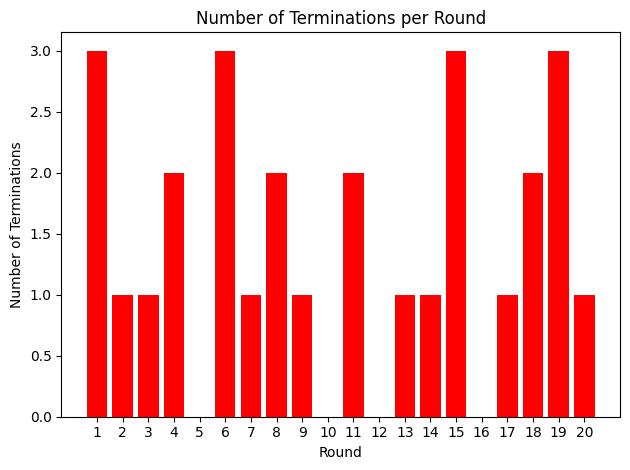

In [10]:
# Extract all terminated columns for the 20 rounds
terminated_columns = [f'bargain_live.{i}.group.terminated' for i in range(1, 21)]

# Filter the relevant data (termination status for 20 rounds)
terminated_data = data[terminated_columns]

# Count the number of terminations per round and divide by 2
terminations_per_round = terminated_data.sum() / 2

# Create a bar plot for terminations per round
plt.bar(range(1, 21), terminations_per_round, color='red')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Number of Terminations')
plt.title('Number of Terminations per Round')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 21))

# Show the plot
plt.tight_layout()
plt.show()

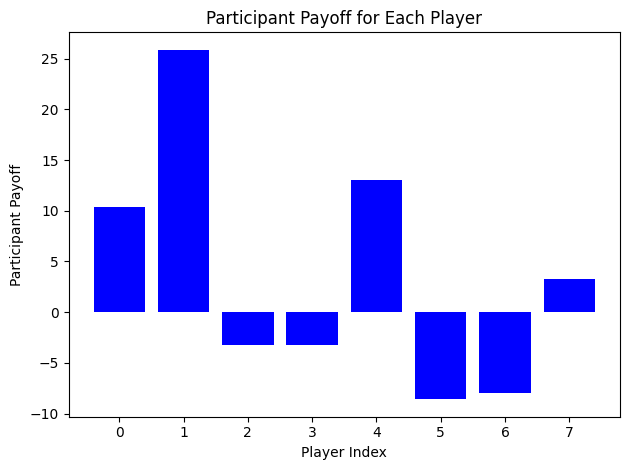

In [11]:
# Extract participant payoff data
participant_payoff = data['participant.payoff']

# Create a bar plot for participant payoffs
plt.bar(data.index, participant_payoff, color='blue')

# Add labels and title
plt.xlabel('Player Index')
plt.ylabel('Participant Payoff')
plt.title('Participant Payoff for Each Player')

# Show the plot
plt.tight_layout()
plt.show()

In [14]:
data.head()

,participant.id_in_session,participant.code,participant.label,participant._is_bot,participant._index_in_pages,participant._max_page_index,participant._current_app_name,participant._current_page_name,participant.time_started_utc,participant.visited,...,bargain_live.20.group.first_proposal_by,bargain_live.20.group.latest_proposal_by,bargain_live.20.group.terminated,bargain_live.20.group.termination_time,bargain_live.20.group.terminated_by,bargain_live.20.group.bargain_start_time,bargain_live.20.group.bargaining_duration,bargain_live.20.group.current_seller_offer,bargain_live.20.group.current_buyer_offer,bargain_live.20.subsession.round_number
0,1,a84q6nzl,NaN,0,100,100,bargain_live,FinalResults,2024-10-04 09:25:16.382714,1,...,NaN,NaN,0,NaN,NaN,1.728045e+09,4.0,15.0,5.0,20
1,2,un6rscuh,NaN,0,100,100,bargain_live,FinalResults,2024-10-04 12:10:10.944277,1,...,NaN,NaN,0,NaN,NaN,1.728045e+09,9.0,29.0,7.0,20
2,3,jvqtayq9,NaN,0,100,100,bargain_live,FinalResults,2024-10-04 12:09:38.419857,1,...,NaN,NaN,0,NaN,NaN,1.728045e+09,9.0,29.0,7.0,20
3,4,tlt5tp22,NaN,0,100,100,bargain_live,FinalResults,2024-10-04 12:10:11.560877,1,...,NaN,NaN,1,16.0,2.0,1.728045e+09,16.0,20.0,1.0,20
4,5,2f42x9sv,NaN,0,100,100,bargain_live,FinalResults,2024-10-04 12:09:40.108231,1,...,NaN,NaN,0,NaN,NaN,1.728045e+09,16.0,28.0,17.0,20


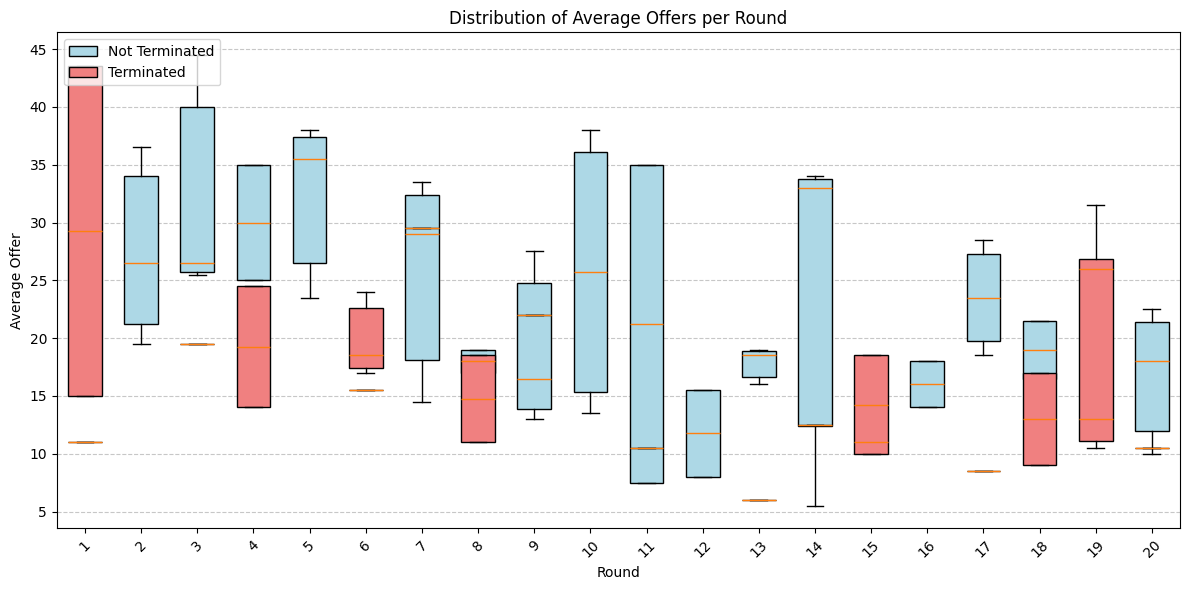

In [21]:
# Extract relevant columns for all 20 rounds
data_for_plot_not_terminated = []
data_for_plot_terminated = []

for i in range(1, 21):
    # Data for non-terminated bargains
    round_data_not_terminated = data[data[f'bargain_live.{i}.group.terminated'] == 0]
    buyer_offer_not_terminated = round_data_not_terminated[f'bargain_live.{i}.group.current_buyer_offer']
    seller_offer_not_terminated = round_data_not_terminated[f'bargain_live.{i}.group.current_seller_offer']
    average_offer_not_terminated = (buyer_offer_not_terminated + seller_offer_not_terminated) / 2
    data_for_plot_not_terminated.append(average_offer_not_terminated.dropna())

    # Data for terminated bargains
    round_data_terminated = data[data[f'bargain_live.{i}.group.terminated'] == 1]
    buyer_offer_terminated = round_data_terminated[f'bargain_live.{i}.group.current_buyer_offer']
    seller_offer_terminated = round_data_terminated[f'bargain_live.{i}.group.current_seller_offer']
    average_offer_terminated = (buyer_offer_terminated + seller_offer_terminated) / 2
    data_for_plot_terminated.append(average_offer_terminated.dropna())

# Create a boxplot of average offers for each round
plt.figure(figsize=(12, 6))

# Plot non-terminated data
bp1 = plt.boxplot(data_for_plot_not_terminated, positions=range(1, 21), widths=0.6, patch_artist=True)
for box in bp1['boxes']:
    box.set(facecolor='lightblue')

# Plot terminated data
bp2 = plt.boxplot(data_for_plot_terminated, positions=range(1, 21), widths=0.6, patch_artist=True)
for box in bp2['boxes']:
    box.set(facecolor='lightcoral')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Average Offer')
plt.title('Distribution of Average Offers per Round')

# Rotate x-axis labels for better readability
plt.xticks(range(1, 21), range(1, 21), rotation=45)

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Not Terminated', 'Terminated'], loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


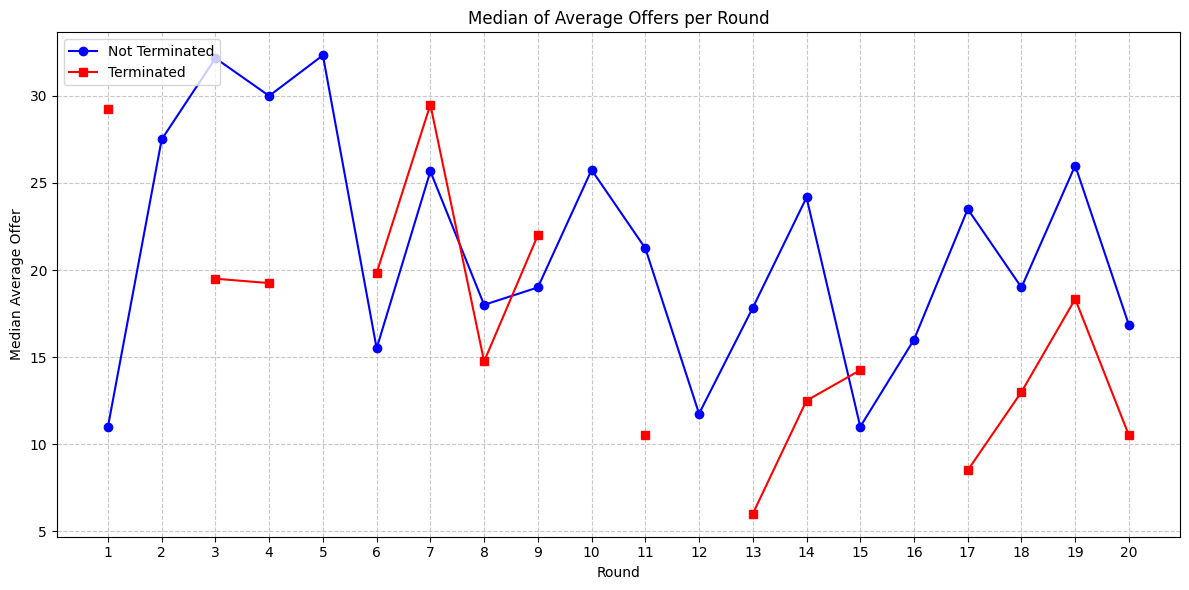

In [24]:
# Extract relevant columns for all 20 rounds
median_not_terminated = []
median_terminated = []

for i in range(1, 21):
    # Data for non-terminated bargains
    round_data_not_terminated = data[data[f'bargain_live.{i}.group.terminated'] == 0]
    buyer_offer_not_terminated = round_data_not_terminated[f'bargain_live.{i}.group.current_buyer_offer']
    seller_offer_not_terminated = round_data_not_terminated[f'bargain_live.{i}.group.current_seller_offer']
    average_offer_not_terminated = (buyer_offer_not_terminated + seller_offer_not_terminated) / 2
    median_not_terminated.append(average_offer_not_terminated.mean())

    # Data for terminated bargains
    round_data_terminated = data[data[f'bargain_live.{i}.group.terminated'] == 1]
    buyer_offer_terminated = round_data_terminated[f'bargain_live.{i}.group.current_buyer_offer']
    seller_offer_terminated = round_data_terminated[f'bargain_live.{i}.group.current_seller_offer']
    average_offer_terminated = (buyer_offer_terminated + seller_offer_terminated) / 2
    median_terminated.append(average_offer_terminated.mean())

# Create a line plot of median average offers for each round
plt.figure(figsize=(12, 6))

# Plot non-terminated data
plt.plot(range(1, 21), median_not_terminated, marker='o', linestyle='-', color='blue', label='Not Terminated')

# Plot terminated data
plt.plot(range(1, 21), median_terminated, marker='s', linestyle='-', color='red', label='Terminated')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Median Average Offer')
plt.title('Median of Average Offers per Round')

# Set x-axis ticks
plt.xticks(range(1, 21))

# Add a grid for easier reading
plt.grid(axis='both', linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()